# human

In [6]:
import pandas as pd
df = pd.read_csv("/home/jiaruil5/personality/llm_personality/psychgenerator_opensource/data/IPIP_NEO_120.csv")
df = df.rename(columns={f"i{i}": i for i in range(1, 121)})
df = df[[i for i in range(1, 121)]]
df

import json
questionnaire = json.load(open("/home/jiaruil5/personality/llm_personality/evaluation/PsychoBench/questionnaire_ipip_neo.json", 'r'))
for i in questionnaire['reverse']:
    df[i] = 6 - df[i]

new_df = pd.DataFrame()
for trait in ['Openness', 'Conscientiousness', 'Extraversion', 'Agreeableness', 'Neuroticism']:
    questions = []
    len_category = 0
    for categories in questionnaire['categories']:
        if trait == categories['cat_name']:
            questions = categories['cat_questions']
            len_category = len(categories['cat_questions'])
            break
    
    tot_scores = 0
    for i in questions:
        tot_scores += df[i]
    tot_scores /= len_category
    new_df[trait] = tot_scores

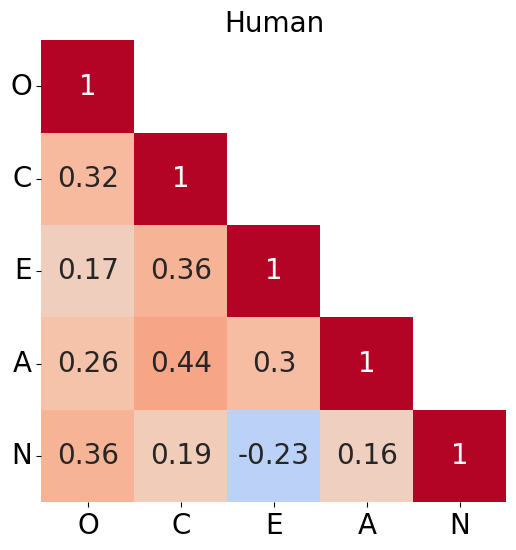

In [8]:
from scipy.stats import skew, kurtosis, probplot
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

human_corr1 = new_df.corr()
# Correlation Matrix
mask = np.triu(np.ones_like(human_corr1, dtype=bool), 1)
plt.figure(figsize=(6, 6))
human_corr1.columns = human_corr1.index = ['O', 'C', 'E', 'A', 'N']
sns.heatmap(human_corr1, mask=mask, annot=True, cmap='coolwarm', vmin=-1, vmax=1, annot_kws={"size": 20}, cbar=False)
# plt.xticks([])
plt.xticks(fontsize=20, rotation=0)
plt.yticks(fontsize=20, rotation=0)
# cbar = plt.gca().collections[0].colorbar
# cbar.ax.tick_params(labelsize=18)
plt.title('Human', fontsize=20)
plt.show()
# plt.savefig("stats/plots/corr/correlation_matrix_human.pdf", format="pdf", bbox_inches="tight")

In [11]:
# Initialize empty DataFrames for correlation coefficients and p-values
corr_matrix = pd.DataFrame(index=new_df.columns, columns=new_df.columns)
pval_matrix = pd.DataFrame(index=new_df.columns, columns=new_df.columns)

# Fill the matrices
for col1 in new_df.columns:
    for col2 in new_df.columns:
        corr, pval = pearsonr(new_df[col1], new_df[col2])
        corr_matrix.loc[col1, col2] = corr
        pval_matrix.loc[col1, col2] = pval

# Convert to float type for formatting
corr_matrix = corr_matrix.astype(float)
pval_matrix = pval_matrix.astype(float)

# Print the matrices
print("Correlation Matrix:")
print(corr_matrix.round(3))

print("\nP-Value Matrix:")
print(pval_matrix.round(3))

Correlation Matrix:
                   Openness  Conscientiousness  Extraversion  Agreeableness  \
Openness              1.000              0.316         0.170          0.260   
Conscientiousness     0.316              1.000         0.361          0.443   
Extraversion          0.170              0.361         1.000          0.300   
Agreeableness         0.260              0.443         0.300          1.000   
Neuroticism           0.360              0.194        -0.229          0.158   

                   Neuroticism  
Openness                 0.360  
Conscientiousness        0.194  
Extraversion            -0.229  
Agreeableness            0.158  
Neuroticism              1.000  

P-Value Matrix:
                   Openness  Conscientiousness  Extraversion  Agreeableness  \
Openness                0.0                0.0           0.0            0.0   
Conscientiousness       0.0                0.0           0.0            0.0   
Extraversion            0.0                0.0       

In [ ]:
from scipy.stats import skew, kurtosis, probplot
import matplotlib.pyplot as plt
import seaborn as sns
# Correlation Matrix
mask = np.triu(np.ones_like(human_corr1, dtype=bool), 1)
plt.figure(figsize=(6, 6))
human_corr1.columns = human_corr1.index = ['O', 'C', 'E', 'A', 'N']
sns.heatmap(human_corr1, mask=mask, annot=True, cmap='coolwarm', vmin=-1, vmax=1, annot_kws={"size": 20}, cbar=False)
# plt.xticks([])
plt.xticks(fontsize=20, rotation=0)
plt.yticks(fontsize=20, rotation=0)
# cbar = plt.gca().collections[0].colorbar
# cbar.ax.tick_params(labelsize=18)
plt.title('Human', fontsize=20)
plt.show()
# plt.savefig("stats/plots/corr/correlation_matrix_human.pdf", format="pdf", bbox_inches="tight")

# method

In [16]:
import json
in_data = [json.loads(i) for i in open("/home/jiaruil5/personality/llm_personality/evaluation/PsychoBench/stats/scores_list_stat_test.jsonl", 'r').readlines()]
data = {
    "data_prompt": {"Openness": [], "Conscientiousness": [], "Extraversion": [], "Agreeableness": [], "Neuroticism": []},
    "data_sft": {"Openness": [], "Conscientiousness": [], "Extraversion": [], "Agreeableness": [], "Neuroticism": []},
    "data_dpo": {"Openness": [], "Conscientiousness": [], "Extraversion": [], "Agreeableness": [], "Neuroticism": []}
}
for i in in_data:
    if "prompt" in i["model_mode"]:
        name = "data_prompt"
    elif "dpo_train" in i["model_mode"]:
        name = "data_dpo"
    elif "train" in i["model_mode"]:
        name = "data_sft"

    for item in i["scores_list"]:
        data[name][item].extend(i["scores_list"][item])

data

{'data_prompt': {'Openness': [4.458333333333333,
   4.291666666666667,
   4.375,
   4.416666666666667,
   4.291666666666667,
   1.4583333333333333,
   1.6666666666666667,
   1.5833333333333333,
   1.4166666666666667,
   1.5,
   2.8333333333333335,
   2.875,
   2.7083333333333335,
   2.8333333333333335,
   2.7916666666666665,
   3.3333333333333335,
   3.4583333333333335,
   3.5416666666666665,
   3.2916666666666665,
   3.375,
   4,
   4.041666666666667,
   4.041666666666667,
   3.875,
   3.9166666666666665,
   2.9166666666666665,
   2.6666666666666665,
   2.7083333333333335,
   2.8333333333333335,
   2.5833333333333335,
   3.5,
   3.2916666666666665,
   3.4166666666666665,
   3.5416666666666665,
   3.5416666666666665,
   2.25,
   2.0416666666666665,
   2.2083333333333335,
   2.25,
   2.3333333333333335,
   3.0416666666666665,
   3.125,
   3,
   3.25,
   3.0416666666666665,
   3.2083333333333335,
   3.0833333333333335,
   3.0833333333333335,
   3.0833333333333335,
   3.125],
  'Conscient

In [1]:
# Your data
data_prompt = {'Openness': [4.4, 1.5, 2.8, 3.4, 4.0, 2.7, 3.5, 2.2, 3.1, 3.1],
  'Conscientiousness': [3.5, 3.6, 4.5, 2.3, 4.1, 3.7, 4.0, 2.8, 2.7, 3.8],
  'Extraversion': [3.8, 2.2, 3.2, 2.9, 5.0, 1.9, 3.8, 2.1, 2.3, 4.0],
  'Agreeableness': [4.2, 3.1, 4.3, 2.6, 3.6, 3.7, 4.6, 2.3, 3.4, 3.2],
  'Neuroticism': [2.5, 3.0, 2.4, 3.1, 2.0, 2.6, 2.4, 2.8, 4.2, 2.6]}

data_sft = {'Openness': [4.3, 1.5, 2.2, 3.4, 3.5, 2.6, 3.2, 2.1, 3.1, 2.9],
  'Conscientiousness': [3.9, 3.7, 4.5, 2.7, 3.9, 3.4, 3.6, 2.6, 2.9, 3.3],
  'Extraversion': [4.1, 2.0, 3.6, 3.0, 5.0, 2.2, 3.7, 3.2, 2.5, 4.2],
  'Agreeableness': [4.4, 3.4, 4.3, 3.0, 3.5, 3.9, 4.0, 1.8, 3.5, 3.6],
  'Neuroticism': [2.5, 2.9, 2.3, 3.0, 2.5, 2.6, 3.5, 3.1, 4.3, 2.0]}

data_dpo = {'Openness': [5.0, 1.9, 3.0, 3.7, 4.1, 2.8, 3.1, 2.1, 3.1, 2.9],
  'Conscientiousness': [3.9, 3.2, 5.0, 2.9, 3.6, 3.2, 4.3, 2.0, 3.1, 3.0],
  'Extraversion': [4.8, 1.8, 3.4, 3.4, 5.0, 1.6, 3.7, 2.9, 2.5, 3.9],
  'Agreeableness': [3.7, 3.6, 4.9, 3.1, 3.4, 3.9, 4.5, 1.2, 3.4, 2.2],
  'Neuroticism': [1.7, 2.8, 1.5, 2.5, 1.8, 2.6, 3.3, 2.9, 3.8, 3.7]}

In [19]:
import pandas as pd
from scipy.stats import pearsonr
df = pd.DataFrame(data['data_dpo'])

# Initialize empty DataFrames for correlation coefficients and p-values
corr_matrix = pd.DataFrame(index=df.columns, columns=df.columns)
pval_matrix = pd.DataFrame(index=df.columns, columns=df.columns)

# Fill the matrices
for col1 in df.columns:
    for col2 in df.columns:
        corr, pval = pearsonr(df[col1], df[col2])
        corr_matrix.loc[col1, col2] = corr
        pval_matrix.loc[col1, col2] = pval

# Convert to float type for formatting
corr_matrix = corr_matrix.astype(float)
pval_matrix = pval_matrix.astype(float)

# Print the matrices
print("Correlation Matrix:")
print(corr_matrix.round(3))

print("\nP-Value Matrix:")
print(pval_matrix.round(3))

Correlation Matrix:
                   Openness  Conscientiousness  Extraversion  Agreeableness  \
Openness              1.000              0.355         0.768          0.273   
Conscientiousness     0.355              1.000         0.301          0.897   
Extraversion          0.768              0.301         1.000         -0.003   
Agreeableness         0.273              0.897        -0.003          1.000   
Neuroticism          -0.469             -0.477        -0.379         -0.390   

                   Neuroticism  
Openness                -0.469  
Conscientiousness       -0.477  
Extraversion            -0.379  
Agreeableness           -0.390  
Neuroticism              1.000  

P-Value Matrix:
                   Openness  Conscientiousness  Extraversion  Agreeableness  \
Openness              0.000              0.011         0.000          0.055   
Conscientiousness     0.011              0.000         0.034          0.000   
Extraversion          0.000              0.034       

prompting: openness vs conscientiousness
sft: openness vs conscientiousness, openness vs neuroticism, extraversion vs agreeableness
dpo: openness vs agreeableness, extraversion vs agreeableness

In [23]:
import json
from statsmodels.stats.inter_rater import fleiss_kappa, aggregate_raters

in_data = [json.loads(i) for i in open("/home/jiaruil5/personality/llm_personality/evaluation/PsychoBench/stats/scores_list_stat_test.jsonl", 'r').readlines()]
data = {
    "data_prompt": [],
    "data_sft": [],
    "data_dpo": []
}
for i in in_data:
    if "prompt" in i["model_mode"]:
        name = "data_prompt"
    elif "dpo_train" in i["model_mode"]:
        name = "data_dpo"
    elif "train" in i["model_mode"]:
        name = "data_sft"

    ratings = []
    for item in i["scores_list"]:
        ratings.append([round(tmp) for tmp in i["scores_list"][item]])

    agg_ratings = aggregate_raters(ratings)[0]
    kappa = fleiss_kappa(agg_ratings)
    data[name].append(kappa)
data

/data/user_data/jiaruil5/miniconda3/envs/new/lib/python3.10/site-packages/statsmodels/stats/inter_rater.py:266: RuntimeWarning: invalid value encountered in scalar divide
  kappa = (p_mean - p_mean_exp) / (1- p_mean_exp)


{'data_prompt': [0.7899159663865545,
  0.7023809523809526,
  0.8263888888888891,
  0.5629370629370629,
  0.8677248677248676,
  0.8774509803921567,
  0.8134328358208956,
  1.0,
  0.8641304347826085,
  0.847560975609756],
 'data_sft': [0.471830985915493,
  0.669603524229075,
  0.6827411167512691,
  nan,
  0.5192307692307692,
  0.6811224489795918,
  0.7023809523809527,
  0.7005988023952098,
  0.7395833333333334,
  0.7500000000000001],
 'data_dpo': [1.0,
  0.8711340206185566,
  0.8179611650485439,
  0.6141975308641976,
  0.8222748815165879,
  0.8036649214659688,
  0.7869318181818183,
  1.0,
  1.0,
  1.0]}

In [26]:
data['data_sft'][3] = 1.0

In [27]:
import numpy as np
np.mean(data['data_prompt']), np.mean(data['data_sft']), np.mean(data['data_dpo'])

(0.8151922964923743, 0.6917091933215693, 0.8716164337695673)